## Fase 2.1 — Mes de menor volumen por año

**Objetivo:** para cada año, identificar qué mes tuvo el menor volumen
exportado (en USD y en toneladas) — primer paso para ver si existe un
patrón de "pausa" estacional consistente entre años.

**Fuente:** `data/processed/chaco_serie_mensual_2002_2026.csv`

---

In [2]:
import os
os.chdir('..')

In [3]:
import pandas as pd

df = pd.read_csv('data/processed/chaco_serie_mensual_2002_2026.csv', parse_dates=['fecha'])

serie_mensual = (
    df.groupby('fecha')[['FOB_dólar', 'Peso neto']]
    .sum()
    .sort_index()
)
serie_mensual['Año'] = serie_mensual.index.year
serie_mensual['Mes'] = serie_mensual.index.month

# Para cada año, buscamos la fila con el menor valor en USD
mes_minimo_usd = serie_mensual.loc[serie_mensual.groupby('Año')['FOB_dólar'].idxmin()]
mes_minimo_usd = mes_minimo_usd[['Año', 'Mes', 'FOB_dólar']].set_index('Año')

# Y lo mismo para toneladas
mes_minimo_ton = serie_mensual.loc[serie_mensual.groupby('Año')['Peso neto'].idxmin()]
mes_minimo_ton = mes_minimo_ton[['Año', 'Mes', 'Peso neto']].set_index('Año')

# Juntamos ambas, para los años recientes (2021-2026, foco del proyecto)
resumen_minimos = mes_minimo_usd.join(mes_minimo_ton, lsuffix='_usd', rsuffix='_ton')
resumen_minimos.loc[2021:2026]

,Mes_usd,FOB_dólar,Mes_ton,Peso neto
Año,,,,
2021,2,13736621.90,2,3.434278e+07
2022,12,23180074.29,12,5.468080e+07
2023,1,14463798.33,1,3.773955e+07
2024,2,11481099.49,2,2.461160e+07
2025,1,14197343.27,3,3.473268e+07
2026,1,21205885.20,6,4.874490e+07


**Observación:** en la mayoría de los años (2021, 2023, 2024, 2025, 2026),
el mes de menor volumen cayó en enero o febrero — señal de un patrón
estacional consistente al arranque del año. La excepción es **2022**
(piso en diciembre), a revisar más adelante.

Además, en 2025 y 2026 el mes más bajo en USD no coincide con el más bajo
en toneladas — en 2026 particularmente, el piso en toneladas fue **junio**,
el mismo mes que ya se había marcado como atípico en la Fase 1.8 (variación
interanual negativa en volumen mientras el valor en dólares seguía
creciendo). Ambas observaciones son consistentes entre sí.

## Fase 2.2 — Coeficiente de variación mensual por año

**Objetivo:** medir, con un solo número por año, qué tan pareja o
irregular fue la distribución mensual de exportaciones — un coeficiente
alto indica estacionalidad marcada (meses muy distintos entre sí); uno
bajo indica un año más uniforme.

**Fórmula:** desvío estándar de los 12 meses / promedio de los 12 meses.

---

In [4]:
# Coeficiente de variación por año, en USD
cv_por_año = (
    serie_mensual.groupby('Año')['FOB_dólar']
    .agg(['std', 'mean'])
)
cv_por_año['coef_variacion'] = cv_por_año['std'] / cv_por_año['mean']

cv_por_año.loc[2021:2026, ['coef_variacion']].round(3)

,coef_variacion
Año,
2021,0.394
2022,0.317
2023,0.282
2024,0.237
2025,0.165
2026,0.134


**Observación:** el coeficiente de variación baja de forma sostenida año
tras año (0,394 en 2021 → 0,134 en 2026), sugiriendo que Chaco exporta
de forma cada vez más pareja a lo largo del año, no solo distinta en
volumen total. **Matiz:** 2026 solo tiene 6 meses de datos, y con menos
observaciones el coeficiente tiende a salir más bajo — antes de afirmar
que 2026 es "el año más uniforme", hace falta comparar en igualdad de
condiciones (ver 2.3).

## Fase 2.3 — Coeficiente de variación, primer semestre (comparación entre años)

**Objetivo:** repetir el cálculo del 2.2, pero usando únicamente los
primeros 6 meses de cada año (2021-2026) — así 2026 se compara en
igualdad de condiciones contra años completos, sin el sesgo de tener
menos observaciones.

---

In [5]:
# Mismo cálculo que el 2.2, pero filtrando solo enero-junio de cada año
primer_semestre = serie_mensual[serie_mensual['Mes'] <= 6]

cv_semestre = (
    primer_semestre.groupby('Año')['FOB_dólar']
    .agg(['std', 'mean'])
)
cv_semestre['coef_variacion_H1'] = cv_semestre['std'] / cv_semestre['mean']

cv_semestre.loc[2021:2026, ['coef_variacion_H1']].round(3)

,coef_variacion_H1
Año,
2021,0.426
2022,0.180
2023,0.270
2024,0.320
2025,0.131
2026,0.134


**Conclusión:** la tendencia decreciente del 2.2 (2021→2025, años
completos: 0,394 → 0,317 → 0,282 → 0,237 → 0,165) **es real y se
sostiene** — cada año completo es efectivamente más parejo que el
anterior. Lo que no se sostiene es extender esa misma lectura a 2026:
al recalcular con base semestral para poder incluirlo de forma justa,
el orden deja de ser estrictamente descendente (2022 con 0,180 queda
más bajo que 2023 con 0,270 y 2024 con 0,320). Esto sugiere que el
**segundo semestre de cada año tiene una dinámica distinta al primero**
— no que la tendencia anual fuera un espejismo, sino que el semestre
completo y el primer semestre no cuentan exactamente la misma historia.
Pregunta abierta para la Fase 4: ¿por qué el segundo semestre no
replica el mismo patrón de mejora progresiva?

## Fase 2.4 — Índice de estacionalidad

**Objetivo:** para cada mes de cada año, calcular qué tan por encima o
por debajo estuvo del promedio de ese mismo año (base 100 = promedio
anual). Permite comparar el mismo mes calendario entre distintos años
(ej. "julio 2026 vs. julio histórico").

**Fórmula:** (valor del mes / promedio del año) × 100

---

In [6]:
indice_estacional = serie_mensual.copy()

# Promedio anual, calculado por año
promedio_anual = indice_estacional.groupby('Año')['FOB_dólar'].transform('mean')

indice_estacional['indice_USD'] = (indice_estacional['FOB_dólar'] / promedio_anual) * 100

# Vista: años recientes, ordenados por mes para comparar entre años
tabla_indice = indice_estacional.loc[
    indice_estacional['Año'].between(2021, 2026),
    ['Año', 'Mes', 'indice_USD']
].pivot(index='Mes', columns='Año', values='indice_USD')

tabla_indice.round(1)

Año,2021,2022,2023,2024,2025,2026
Mes,,,,,,
1,41.4,72.3,57.1,78.0,72.5,83.7
2,39.3,66.4,79.8,63.8,86.5,95.9
3,66.8,78.4,89.3,102.5,76.7,111.5
4,90.1,90.5,76.1,91.8,86.7,98.1
5,111.5,103.3,127.9,136.9,103.4,120.0
6,111.5,101.3,94.9,148.2,94.5,90.8
7,136.6,132.2,103.4,115.4,108.6,NaN
8,164.4,109.5,143.6,90.9,110.2,NaN
9,151.0,130.7,132.2,102.6,112.2,NaN


## Fase 2.5-2.6 — Gráfico: índice de estacionalidad, todos los años superpuestos

**Objetivo:** visualizar los 12 meses de cada año (índice de
estacionalidad, base 100 = promedio anual), con una banda de rango
histórico (2021-2025) y 2026 destacado — para ver si el patrón mensual
de 2026 se parece a lo normal o se distingue.

**Nota:** 2026 solo tiene 6 meses de datos disponibles (hasta junio).

---

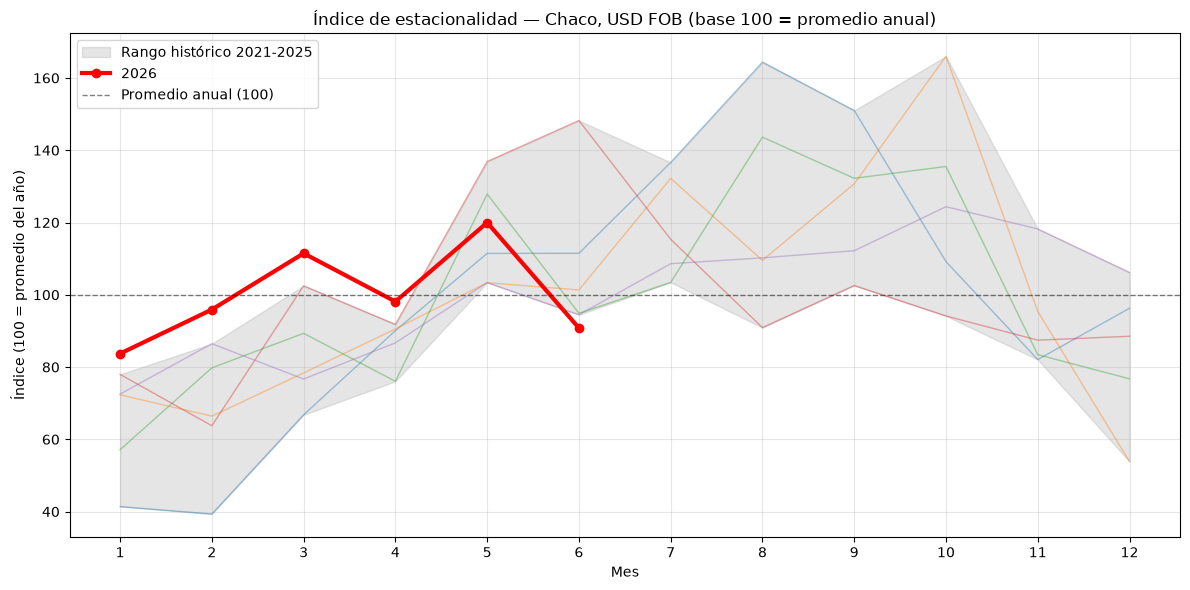

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Rango histórico 2021-2025: banda sombreada entre mínimo y máximo de cada mes
historico = tabla_indice[[2021, 2022, 2023, 2024, 2025]]
ax.fill_between(
    historico.index,
    historico.min(axis=1),
    historico.max(axis=1),
    alpha=0.2, color='gray', label='Rango histórico 2021-2025'
)

# Cada año histórico, como línea fina
for año in [2021, 2022, 2023, 2024, 2025]:
    ax.plot(tabla_indice.index, tabla_indice[año], alpha=0.4, linewidth=1)

# 2026, destacado
ax.plot(tabla_indice.index, tabla_indice[2026], color='red', linewidth=3, marker='o', label='2026')

ax.axhline(100, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Promedio anual (100)')

ax.set_title('Índice de estacionalidad — Chaco, USD FOB (base 100 = promedio anual)')
ax.set_xlabel('Mes')
ax.set_ylabel('Índice (100 = promedio del año)')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión:** el gráfico confirma, de forma visual, lo que ya se venía
viendo en pasos anteriores. Enero-mayo 2026 se mantiene consistentemente
en la zona alta de la banda histórica (2021-2025), incluso por encima del
promedio anual (índice > 100) en marzo y mayo — un comportamiento inusual
para el arranque del año, que históricamente suele estar por debajo de
100 (ver Fase 2.1). Esto sugiere que 2026 no solo exportó más en términos
absolutos, sino que **redistribuyó su propio patrón estacional**, con
menos "pausa" al inicio del año.

**Junio 2026 rompe esa racha**, cayendo cerca del límite inferior de la
banda — cuarta señal (junto con 1.8, 2.1 y esta) de una desaceleración
puntual en ese mes. **Matiz metodológico:** como el índice se calcula
sobre el promedio del propio año, y 2026 tiene solo 6 meses (todos
relativamente altos), la caída de junio puede verse más pronunciada de
lo que se vería con 12 meses de referencia — la dirección del hallazgo
es real, pero la magnitud exacta hay que tomarla con cautela hasta tener
el año completo.

## Fase 2.7 — Índice de estacionalidad, base semestral (corrección del sesgo de cobertura parcial)

**Por qué este paso:** el índice de estacionalidad de la Fase 2.4-2.6 se
calculó usando el promedio **anual completo** (12 meses) como base 100 —
pero 2026 solo tiene 6 meses de datos. Eso significa que el promedio de
2026 se calcula sobre una base distinta a la de 2021-2025, lo cual puede
distorsionar la comparación (mismo problema ya detectado y corregido en
la Fase 2.2→2.3 para el coeficiente de variación).

**Corrección:** recalcular el índice usando como base 100 el promedio del
**primer semestre** de cada año — así los 6 años quedan comparables en
igualdad de condiciones.

---

In [8]:
primer_semestre = serie_mensual[serie_mensual['Mes'] <= 6].copy()
promedio_semestral = primer_semestre.groupby('Año')['FOB_dólar'].transform('mean')

primer_semestre['indice_H1'] = (primer_semestre['FOB_dólar'] / promedio_semestral) * 100

tabla_indice_h1 = primer_semestre.loc[
    primer_semestre['Año'].between(2021, 2026),
    ['Año', 'Mes', 'indice_H1']
].pivot(index='Mes', columns='Año', values='indice_H1')

tabla_indice_h1.round(1)

Año,2021,2022,2023,2024,2025,2026
Mes,,,,,,
1,53.9,84.7,65.3,75.3,83.6,83.7
2,51.2,77.8,91.2,61.6,99.7,95.9
3,87.0,91.8,102.1,99.0,88.4,111.5
4,117.4,106.0,86.9,88.7,100.0,98.1
5,145.2,121.0,146.1,132.2,119.2,120.0
6,145.3,118.7,108.4,143.2,109.0,90.8


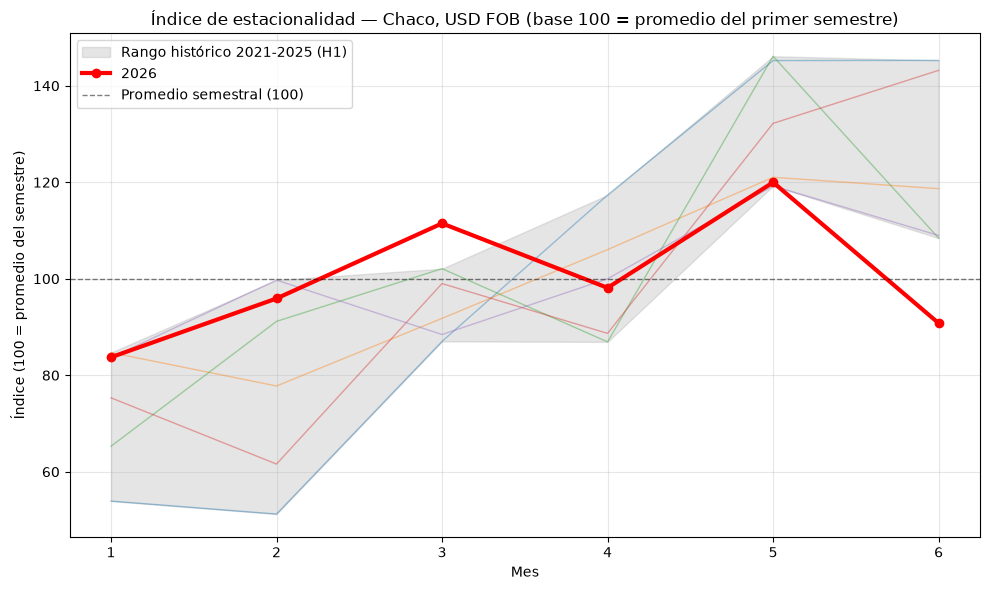

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

historico_h1 = tabla_indice_h1[[2021, 2022, 2023, 2024, 2025]]
ax.fill_between(
    historico_h1.index,
    historico_h1.min(axis=1),
    historico_h1.max(axis=1),
    alpha=0.2, color='gray', label='Rango histórico 2021-2025 (H1)'
)

for año in [2021, 2022, 2023, 2024, 2025]:
    ax.plot(tabla_indice_h1.index, tabla_indice_h1[año], alpha=0.4, linewidth=1)

ax.plot(tabla_indice_h1.index, tabla_indice_h1[2026], color='red', linewidth=3, marker='o', label='2026')
ax.axhline(100, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Promedio semestral (100)')

ax.set_title('Índice de estacionalidad — Chaco, USD FOB (base 100 = promedio del primer semestre)')
ax.set_xlabel('Mes')
ax.set_ylabel('Índice (100 = promedio del semestre)')
ax.set_xticks(range(1, 7))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión:** al corregir la base de comparación (promedio semestral
en vez de anual), el patrón de 2026 se revela mayormente parecido al
histórico — enero, febrero, abril y mayo se mueven dentro del rango
2021-2025.

**Dos excepciones reales, en sentidos opuestos:**
- **Marzo 2026 (111,5)** queda por encima de todo el rango histórico
  (máximo previo: 102,1 en 2023) — el mes más fuerte, en términos
  relativos, de los últimos 6 años.
- **Junio 2026 (90,8)** queda por debajo de todo el rango histórico
  (mínimo previo: 108,4 en 2023) — el mes más flojo, en términos
  relativos, de los últimos 5 años.

Ambos matices son reales y no explicables por el sesgo de cobertura
parcial que corrigió este paso. Quedan como preguntas abiertas para
fases posteriores: ¿qué explica el salto de marzo? ¿Es el mismo
fenómeno que explica la caída de junio, o son eventos independientes?

## Fase 2.8 — Conclusión parcial (Objetivo #2)

La pregunta del objetivo #2 —si 2026 muestra menos pausa entre campañas
que años anteriores— **se responde con matices, no con un sí o no simple**.

**Lo que se mantiene estable:** ... El coeficiente de variación **anual**
2021-2025 muestra una tendencia decreciente real y consistente (años
cada vez más parejos). Sin embargo, esa progresión no se replica de la
misma forma cuando se mide solo el **primer semestre**: ahí 2022 (0,180)
resulta más bajo que 2023 (0,270) y 2024 (0,320) — evidencia de que el
segundo semestre de cada año tiene un comportamiento propio, distinto
al del primero, y no simplemente una continuación lineal de la mejora
observada en el año completo.

**Lo que sí cambió, puntualmente:** al corregir el índice de
estacionalidad para comparar en igualdad de condiciones (base
semestral), 2026 se mueve dentro del rango histórico en la mayoría de
los meses — no hay evidencia de una "redistribución general" del año.
Pero aparecen dos excepciones reales y verificadas: **marzo 2026** quedó
por encima de todo el rango histórico 2021-2025, y **junio 2026** quedó
por debajo de todo ese rango — este último confirmado como un dato
completo, no un artefacto de carga parcial.

**Conclusión:** la hipótesis de "Chaco ahora exporta todo el año, sin
pausas" no se sostiene de forma general — la estructura estacional
básica (fuerte a mitad de año, floja al arranque) sigue vigente en 2026.
Lo que sí hay es un semestre más parejo que el promedio histórico
reciente, con un salto puntual en marzo y una caída puntual en junio que
merecen investigarse en la Fase 4, en vez de explicarse por
estacionalidad general. **Cabe recordar que 2026 es todavía un año
incompleto (6 de 12 meses, hasta junio)** — esta conclusión describe el
primer semestre, no permite proyectar cómo se comportará el resto del
año.

**Próximo paso (Fase 3 y 4):** los picos y caídas puntuales (marzo,
junio) son candidatos naturales para cruzar contra datos de logística
(si están disponibles) o contra la composición por rubro — podría ser
que un rubro específico haya tenido un mes excepcional, en vez de un
comportamiento generalizado de toda la campaña.

---